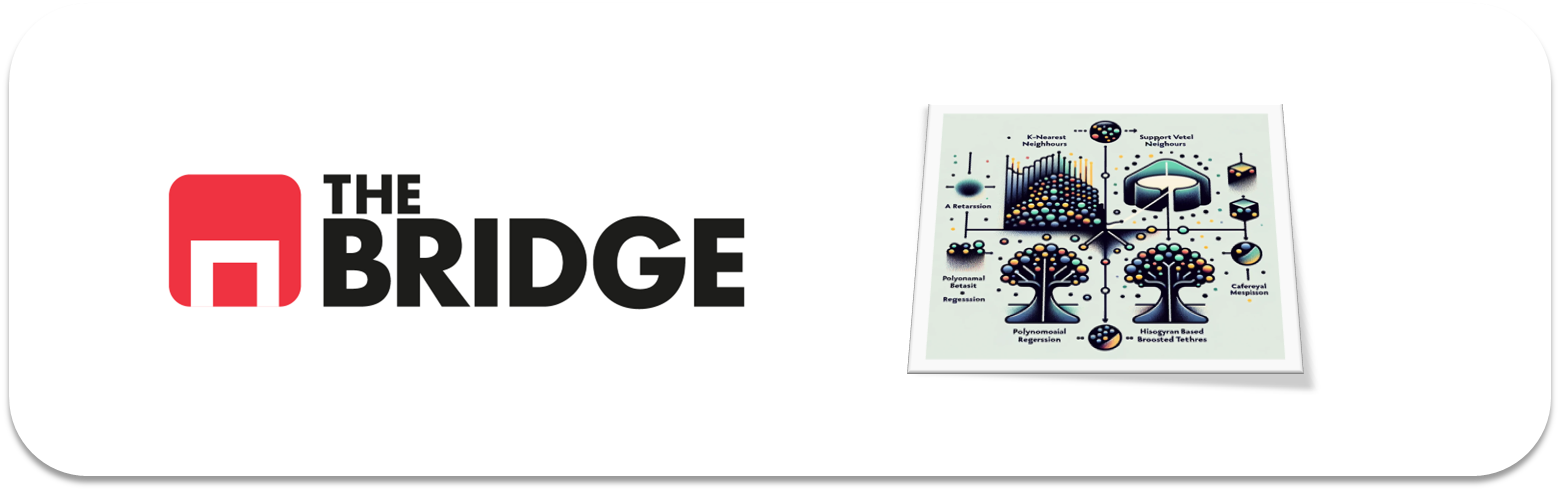

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from imblearn import over_sampling
from sklearn import model_selection, tree, linear_model, metrics, utils, ensemble, impute, preprocessing, neighbors

import lightgbm
import xgboost

from bootcampviztools import pinta_distribucion_categoricas, plot_categorical_relationship_fin, plot_grouped_histograms
from toolbox_ML import describe_df, tipifica_variables, get_features_num_regression, plot_features_num_regression, get_features_cat_regression, plot_features_cat_regression

pd.set_option('display.max_columns', None)

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [37]:
df = pd.read_csv('./data/credit_npo.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [38]:
df.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
5,0,0.101002,61,0,0.217115,15880.0,5,0,1,0,0.0
6,0,0.222830,60,0,0.907083,1312.0,5,0,0,0,0.0
7,0,0.353443,39,0,0.764309,4000.0,11,0,1,0,2.0
8,0,0.772455,45,0,0.387179,5100.0,5,0,1,0,3.0
9,0,0.116165,44,0,0.160236,10833.0,8,0,1,0,0.0


#### SeriousDlqin2yrs
Variable binaria que indica si el cliente tendrá un impago grave (≥90 días de retraso) en los próximos dos años.

#### RevolvingUtilizationOfUnsecuredLines
Porcentaje de utilización del crédito disponible en líneas no garantizadas (tarjetas, crédito personal).

#### age
Edad del cliente en años.

#### NumberOfTime30-59DaysPastDueNotWorse
Número de veces que el cliente tuvo retrasos de entre 30 y 59 días en sus pagos sin llegar a impago grave.

#### DebtRatio
Ratio entre la deuda mensual total del cliente y sus ingresos mensuales.

#### MonthlyIncome
Ingresos mensuales del cliente.

#### NumberOfOpenCreditLinesAndLoans
Número total de líneas de crédito y préstamos activos del cliente.

#### NumberOfTimes90DaysLate
Número de veces que el cliente tuvo retrasos de 90 días o más en sus pagos.

#### NumberRealEstateLoansOrLines
Número de préstamos o líneas de crédito asociadas a bienes inmuebles.

#### NumberOfTime60-89DaysPastDueNotWorse
Número de veces que el cliente tuvo retrasos de entre 60 y 89 días sin llegar a impago grave.

#### NumberOfDependents
Número de personas económicamente dependientes del cliente.

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

De clasificación binaria con la variable target SeriousDlqin2yrs para predecir si el cliente dará problemas.

In [39]:
target = 'SeriousDlqin2yrs'

### #1.3
Pinta la distribución de frecuencias del target y coméntala

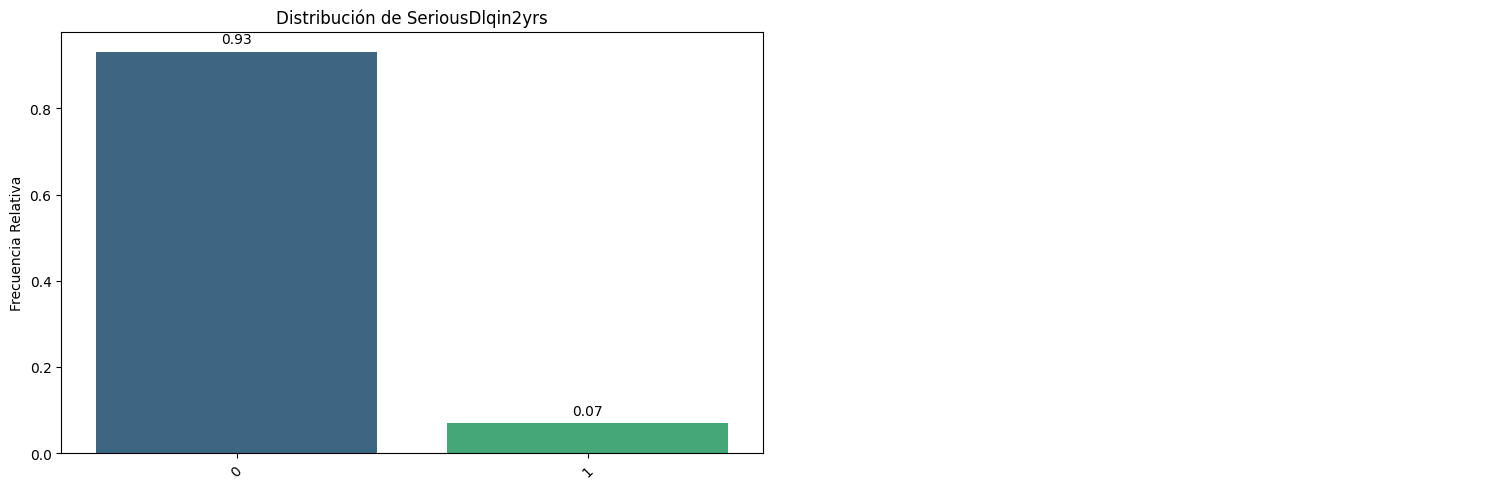

In [40]:
pinta_distribucion_categoricas(df, [target], True, True)

Se trata de un problema de clasificación claramente desbalanceado.

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [41]:
train, test = model_selection.train_test_split(df, test_size=0.2, random_state=42, stratify=df[target])

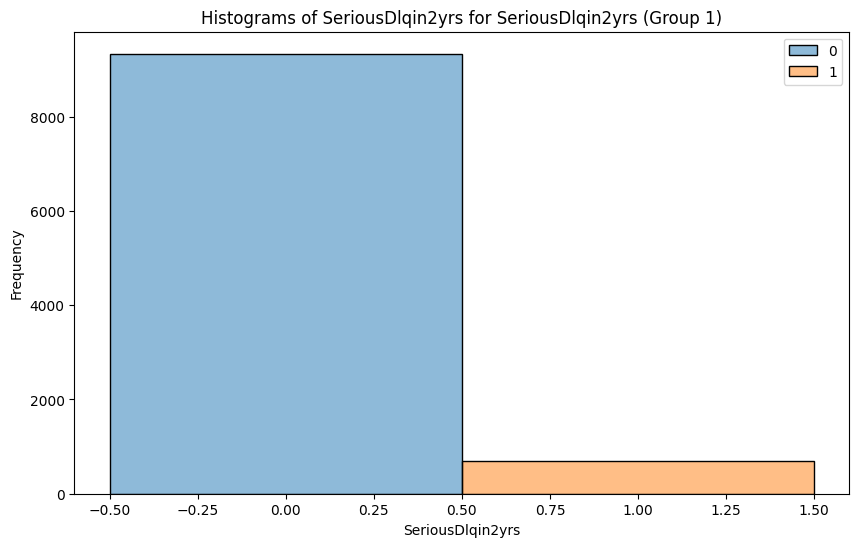

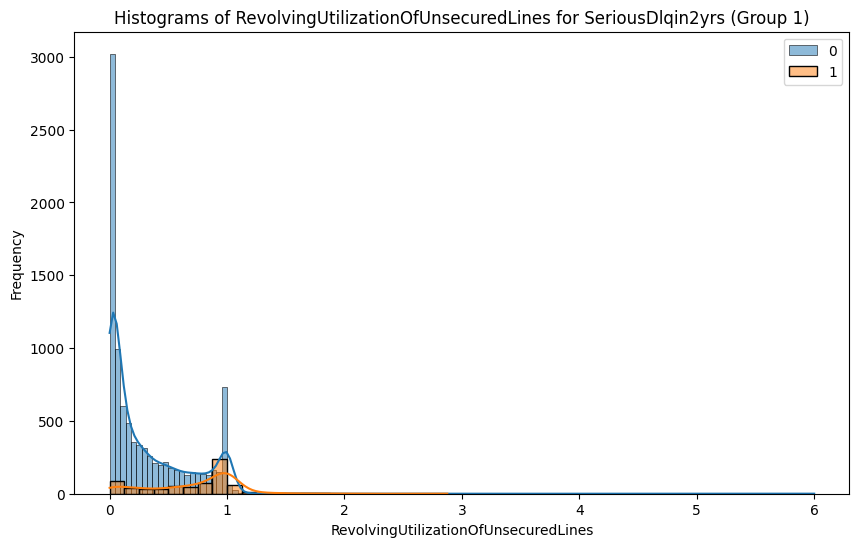

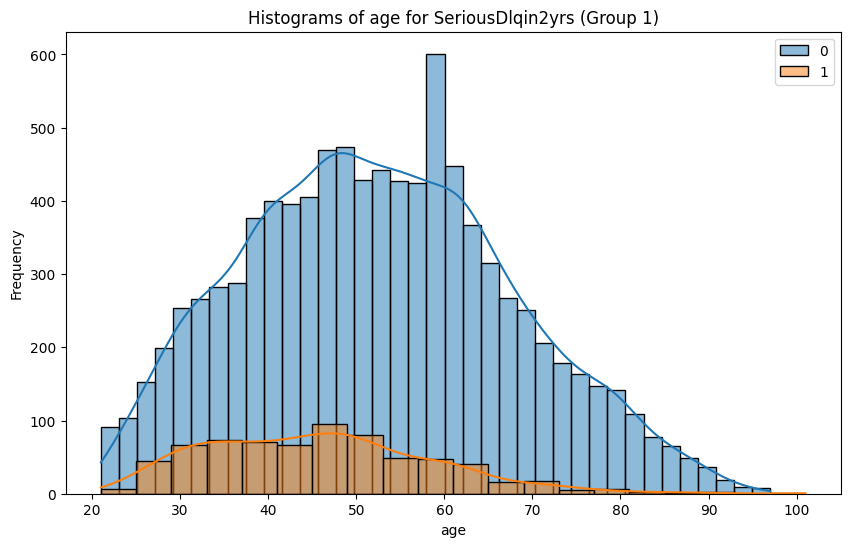

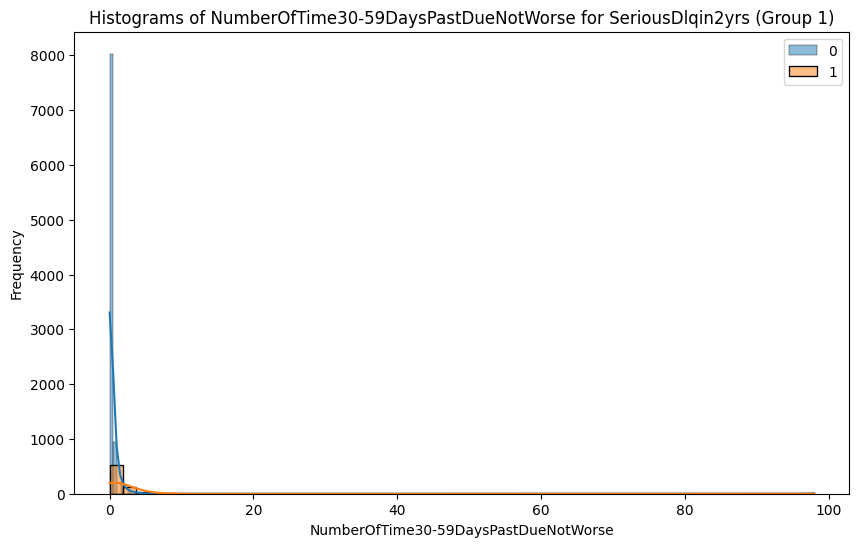

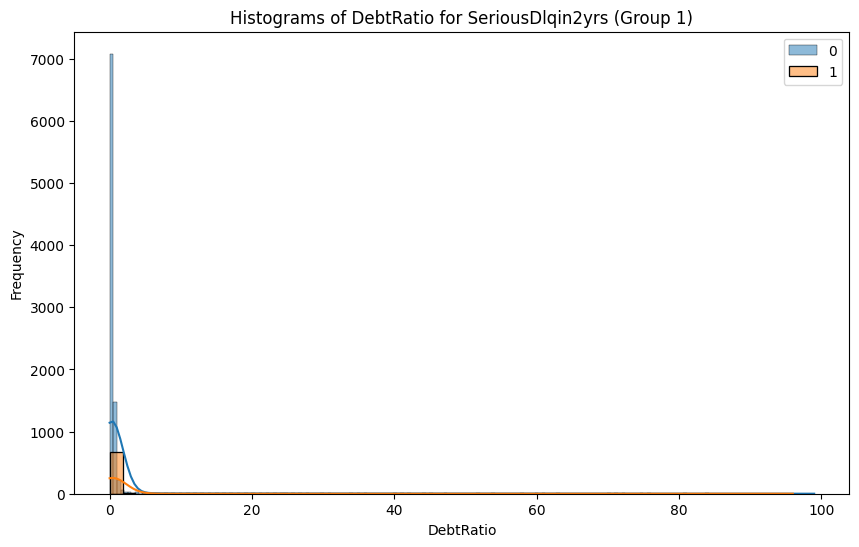

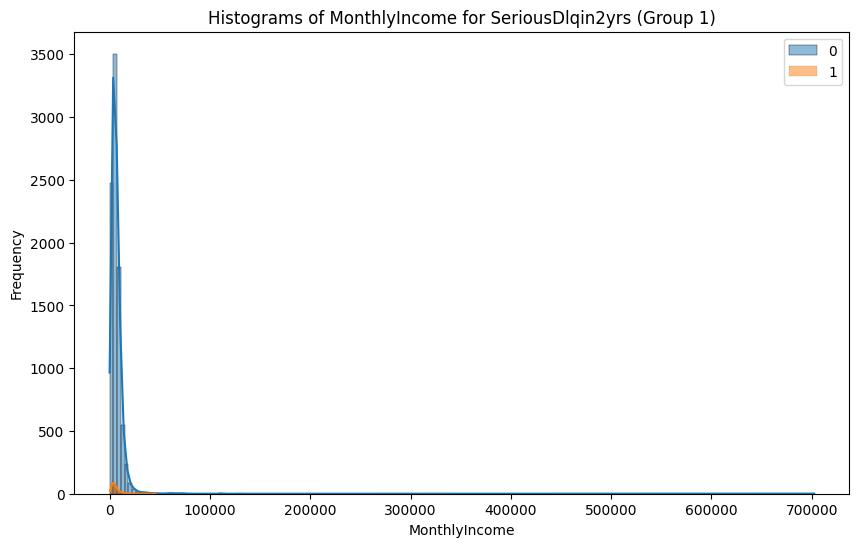

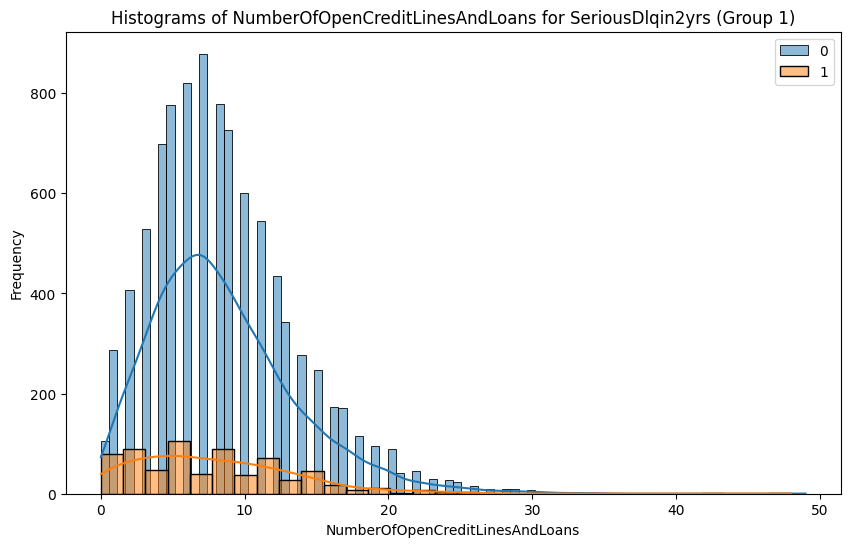

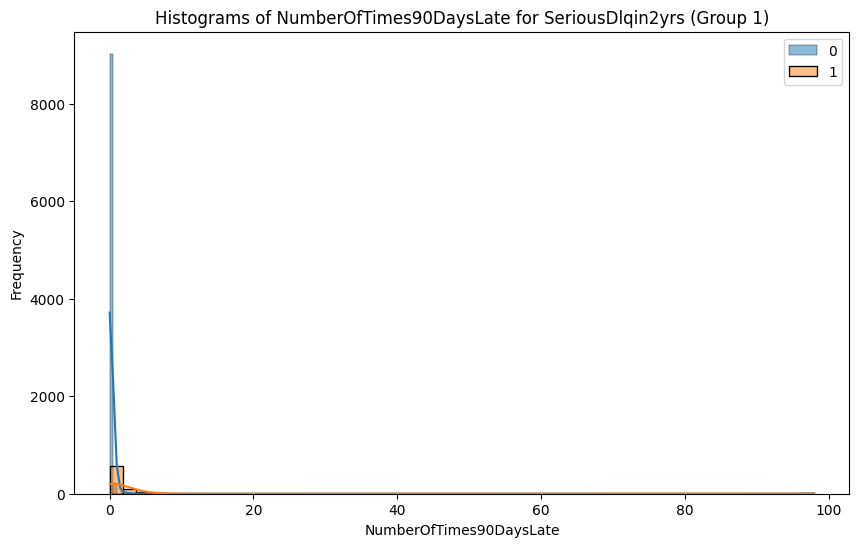

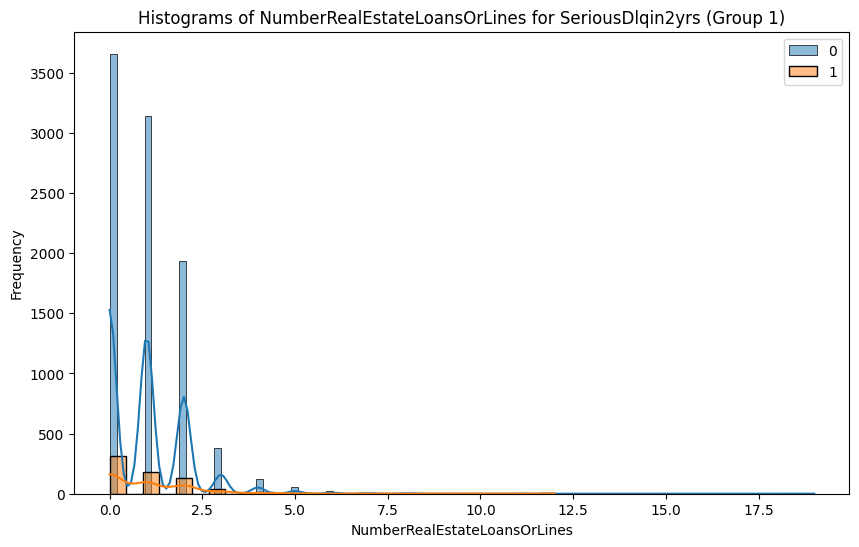

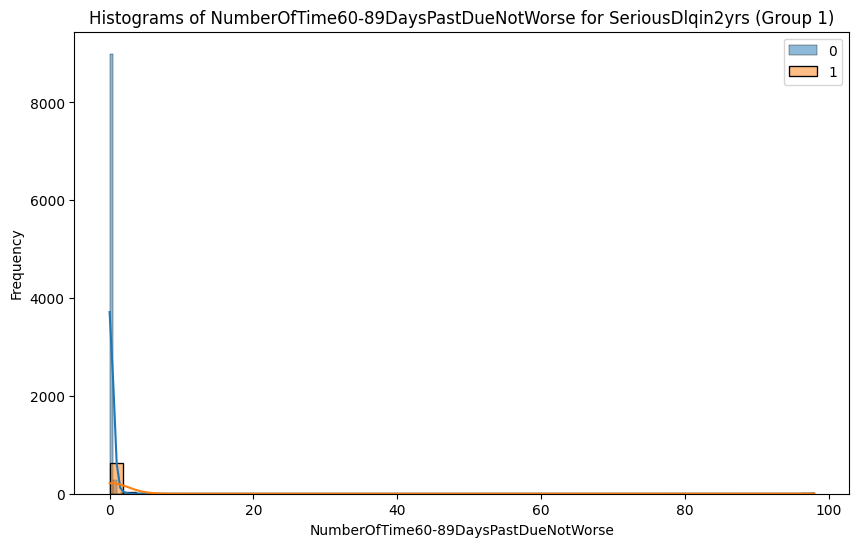

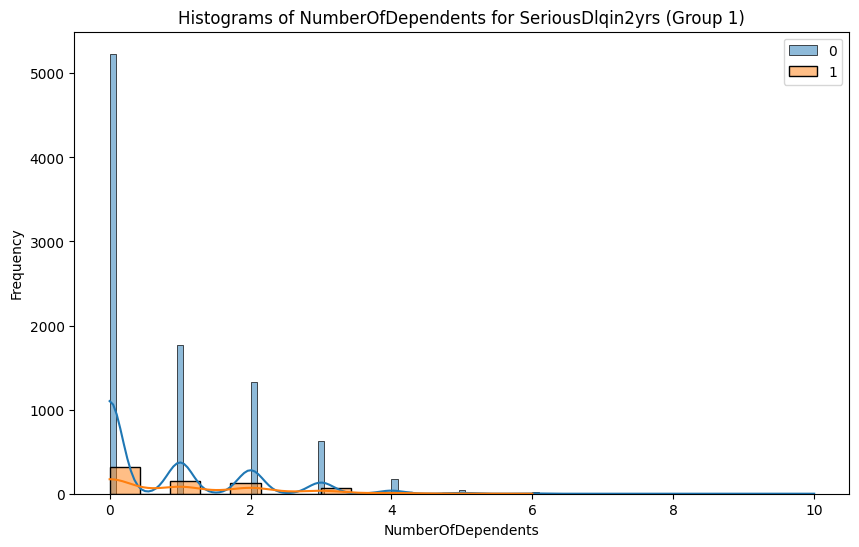

In [42]:
for col in train.columns:
    plot_grouped_histograms(train, cat_col= target, num_col= col, group_size= 3)

In [43]:
X_train = train.drop(columns=target)
y_train = train[target]

X_test = test.drop(columns=target)
y_test = test[target]

In [44]:
imputer = impute.SimpleImputer(strategy='median')

X_train[X_train.columns] = imputer.fit_transform(X_train)
X_test[X_test.columns] = imputer.transform(X_test)

In [45]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10029 entries, 8818 to 10443
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      10029 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  10029 non-null  float64
 2   age                                   10029 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  10029 non-null  int64  
 4   DebtRatio                             10029 non-null  float64
 5   MonthlyIncome                         9446 non-null   float64
 6   NumberOfOpenCreditLinesAndLoans       10029 non-null  int64  
 7   NumberOfTimes90DaysLate               10029 non-null  int64  
 8   NumberRealEstateLoansOrLines          10029 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  10029 non-null  int64  
 10  NumberOfDependents                    9888 non-null   float64
dtypes: float64(4), in

In [46]:
columnas_outliers = ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

X_train_scaled = X_train.copy()
clip = {}
for col in columnas_outliers:
    clip[col] = train[col].quantile(0.99)
    X_train_scaled[col] = X_train_scaled[col].clip(upper=clip[col])
    X_train_scaled[col] = np.log(X_train_scaled[col] + 1)

X_test_scaled = X_test.copy()
for col in columnas_outliers:
    X_test_scaled[col] = X_test_scaled[col].clip(upper=clip[col])
    X_test_scaled[col] = np.log(X_test_scaled[col] + 1)

In [47]:
scaler = preprocessing.RobustScaler()

X_train_scaled[X_train_scaled.columns] = scaler.fit_transform(X_train_scaled)

X_test_scaled[X_test_scaled.columns] = scaler.transform(X_test_scaled)

In [48]:
smote = over_sampling.SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [49]:
### KNNeighbors

param_grid = {
    "n_neighbors": np.arange(1, 20, 2) 
}

kn_clf = neighbors.KNeighborsClassifier()

kn_grid = model_selection.GridSearchCV(kn_clf,
                                       param_grid=param_grid,
                                       cv=5,
                                       scoring="recall_macro",
                                       verbose=1
                                       )

kn_grid.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])},
             scoring='recall_macro', verbose=1)

In [50]:
kn_grid.best_score_

np.float64(0.9417964614761741)

In [51]:
print(metrics.classification_report(y_test, kn_grid.predict(X_test_scaled)))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2335
           1       0.23      0.36      0.29       173

    accuracy                           0.87      2508
   macro avg       0.59      0.64      0.61      2508
weighted avg       0.90      0.87      0.89      2508



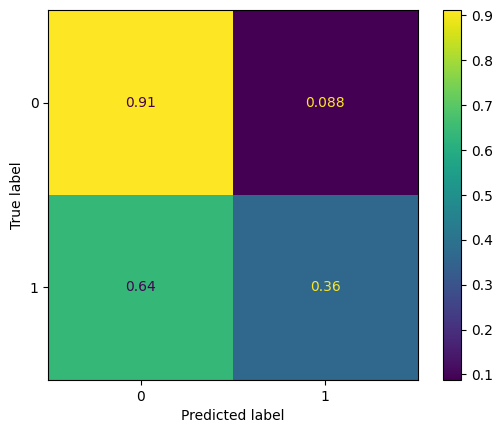

In [52]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, kn_grid.predict(X_test_scaled), normalize= "true") 

In [53]:
### RandomForest

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [5, 10],
    "min_samples_leaf": [10, 20, 100],
    "max_features": ["sqrt", "log2"]
}

rf_clf = ensemble.RandomForestClassifier(random_state=42, class_weight='balanced')

rf_grid = model_selection.GridSearchCV(rf_clf,
                                       param_grid=param_grid,
                                       cv=5,
                                       scoring="recall_macro",
                                       verbose=1
                                       )

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [5, 10], 'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [10, 20, 100],
                         'n_estimators': [100, 200, 400]},
             scoring='recall_macro', verbose=1)

In [54]:
rf_grid.best_score_

np.float64(0.7699736389854256)

In [55]:
print(metrics.classification_report(y_test, rf_grid.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.79      0.87      2335
           1       0.21      0.74      0.32       173

    accuracy                           0.79      2508
   macro avg       0.59      0.77      0.60      2508
weighted avg       0.92      0.79      0.84      2508



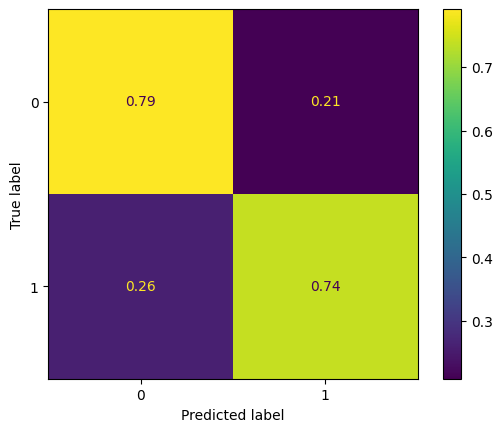

In [56]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, rf_grid.predict(X_test), normalize= "true")

In [57]:
### XGBoost

param_grid = {
    "n_estimators": [100, 200, 400],
    "eta": [0.1, 0.3, 0.6], # Learning rate
    "max_depth": [5, 10], # Stumps
    "min_child_weight": [10, 20, 100],
    "colsample_bytree": [0.5, 1] # max_features sqrt, 
}

xgb_clf = xgboost.XGBClassifier(random_state=42, scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))

xgb_grid = model_selection.GridSearchCV(xgb_clf,
                                        param_grid=param_grid,
                                        cv=5,
                                        scoring="recall_macro",
                                        verbose=1
                                        )

xgb_grid.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.5, 1], 'eta': [0.1, 0.3, 0.6],
                         'max_depth': [5, 10],
                         'min_child_weight': [10, 20, 100],
                         'n_estimators': [100, 200, 400]},
             scoring='recall_macro', verbose=1)

In [58]:
xgb_grid.best_score_

np.float64(0.7643897386873345)

In [59]:
print(metrics.classification_report(y_test, xgb_grid.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.82      0.89      2335
           1       0.23      0.73      0.35       173

    accuracy                           0.81      2508
   macro avg       0.60      0.77      0.62      2508
weighted avg       0.92      0.81      0.85      2508



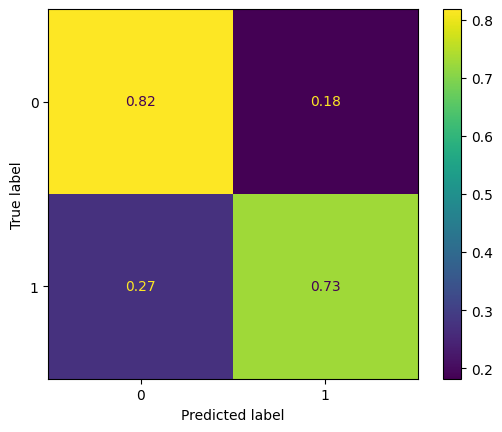

In [60]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, xgb_grid.predict(X_test), normalize= "true")